# MU5EEB13: Sensori-motor behavior, motor learning, haptic function

## TP1 Forearm movements and LQR model

**Organization and evaluation**:

The evaluation will be based on 8 labs (4 with *Olivier Sigaud*, 3 with *Julien Gori*, 1 with *David Gueorguiev*) and a journal club oral presentation (with *Malika Auvray* and *Emmanuel Guigon*). The 9 marks (on 100) will be combined to give the final mark (on 100) according to 0.1 x (Lab1 + .. + Lab8) + 0.2 x journal club.

**Teachers and lecturers**: 
- Olivier Sigaud - mail: olivier.sigaud@sorbonne-universite.fr
- David Gueorguiev - mail: gueorguiev@isir.upmc.fr
- Julien Gori - mail: gori@isir.upmc.fr
- Malika Auvray - mail: malika.auvray@sorbonne-universite.fr
- Emmanuel Guigon - mail: emmanuel.guigon@sorbonne-universite.fr

**Student**: William WU - mail: william.wu@etu.sorbonne-universite.fr

___




# Introduction

In this lab, we will apply Proximal Policy Optimization (PPO) to control a forearm model, moving beyond the restrictive assumptions of LQR. Using `stable-baselines3` and the Gym API, we will implement a reinforcement learning environment, train a PPO agent, and compare its performance to the optimal LQR policy. First we will install `stable-baselines3` and the required libraries.

In [ ]:
%pip install stable-baselines3
%pip install tensorboard
%pip install control
%pip install tqdm rich

In [1]:
import matplotlib.pyplot as plt
import numpy as np  
import tensorboard
import gymnasium as gym
from gymnasium import spaces
import control as ct

___

## Task 5: Formulation of the Forearm Model as a MDP

To apply a reinforcement learning algorithm to the forearm movement problem, the system must first be formulated as a Markov Decision Process (MDP). An MDP is defined by the tuple $\left( \mathcal{S}, \mathcal{A}, P, R, \gamma \right),$ where $\mathcal{S}$ is the state space, $\mathcal{A}$ the action space, $P$ the state transition function, $R$ the reward function, and $\gamma$ the discount factor.

### State Space

The state of the system is defined as the physical state of the forearm, identical to the state used in the LQR formulation:
$
x_k =
\begin{bmatrix}
\theta_k \
\dot{\theta}_k
\end{bmatrix},
$
where $\theta_k$ denotes the angular position of the forearm and $\dot{\theta}_k$ its angular velocity at discrete time step $k$.

The observation provided to the agent is the full system state. The state space is therefore continuous and two-dimensional: $\mathcal{S} \subset \mathbb{R}^2.$

### Action Space

The action corresponds to the control torque applied at the elbow joint: $u_k = \tau_k.$

To ensure numerical stability and facilitate learning with PPO, the action space is defined as a bounded continuous interval: $\mathcal{A} = [\tau_{\min}, \tau_{\max}],$ where the bounds are chosen consistently with the torque magnitudes observed in the previous LQR-based simulations.

### State Transition Dynamics

The system dynamics follow the discretized forearm model introduced in the previous lab. Using a forward Euler discretization with sampling period $T$, the state transition is given by
*$*
x_{k+1} = A x_k + B u_k,
$

$
\text{with} \quad
A =
\begin{bmatrix}
1 & T \
0 & 1 - \frac{bT}{I}
\end{bmatrix},
\quad
B =
\begin{bmatrix}
0 \
\frac{T}{I}
\end{bmatrix},
$
where $I$ is the moment of inertia and $b$ the viscous friction coefficient. The transition dynamics are deterministic and noise-free.

### Reward Function

The reward function is defined to mirror exactly the quadratic cost used in the LQR formulation. At each time step, the agent receives the reward:
$$
r_k = -\left( x_k^\top Q x_k + u_k^\top R u_k \right),
$$
where $Q$ penalizes deviations of the state and $R$ penalizes control effort. This definition ensures direct comparability between the optimal control solution obtained with LQR and the policy learned via PPO.

### Termination Condition

An episode terminates either when a fixed time horizon $N$ is reached or when the system state is sufficiently close to the target configuration, defined by
$$
|\theta_k| < \varepsilon_\theta
\quad \text{and} \quad
|\dot{\theta}*k| < \varepsilon*{\dot{\theta}}.
$$
This stopping criterion reflects successful completion of the movement.

### Discount Factor

The discount factor is chosen close to unity: $\gamma \approx 0.99,$ corresponding to a long-horizon optimization problem consistent with the finite-horizon LQR formulation.

___

## Task 6: Implementation of the Forearm Gym Environment

The forearm model introduced previously is implemented as a Gym-compatible environment in order to be used with model-free reinforcement learning algorithms. The environment follows the Gym API and encapsulates the system dynamics, reward structure, and termination conditions.

The environment state is defined as
$$
x_k =
\begin{bmatrix}
\theta_k \\
\dot{\theta}_k
\end{bmatrix},
$$
where $\theta_k$ is the angular position of the forearm and $\dot{\theta}_k$ its angular velocity.  
The control action corresponds to the torque applied at the elbow joint, $u_k = \tau_k$ .

State transitions follow the discretized linear dynamics of the forearm model derived in the previous lab. Using a forward Euler discretization with sampling period $T$, the system evolves according to
$$
x_{k+1} = A x_k + B u_k,
$$

$$
\text{with} \quad
A =
\begin{bmatrix}
1 & T \\
0 & 1 - \frac{bT}{I}
\end{bmatrix},
\quad
B =
\begin{bmatrix}
0 \\
\frac{T}{I}
\end{bmatrix},
$$
where $I$ denotes the moment of inertia and $b$ the viscous friction coefficient. The state transitions are deterministic and noise-free.

An episode terminates when either a fixed time horizon $N$ is reached or when the system state converges sufficiently close to the target configuration, defined by
$$
|\theta_k| < \varepsilon_\theta
\quad \text{and} \quad
|\dot{\theta}_k| < \varepsilon_{\dot{\theta}}.
$$
This termination criterion reflects successful completion of the movement.

In [2]:
class ForeArmModel(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self):
        super().__init__()

        # Physical parameters
        self.I = 0.25        # moment of inertia
        self.b = 0.2         # viscous friction
        self.T = 0.01        # sampling period (10 ms)

        # Discrete-time dynamics matrices
        self.A = np.array([
            [1.0, self.T],
            [0.0, 1.0 - self.b * self.T / self.I]
        ])

        self.B = np.array([
            [0.0],
            [self.T / self.I]
        ])

        # Cost matrices (same as LQR)
        self.Q = np.array([[1.0, 0.0], [0.0, 0.0]])
        self.R = np.array([[1e-3]])

        # Action space: normalized
        self.tau_max = 30.0  # physical torque limit

        self.action_space = spaces.Box(
            low=-1.0,
            high=1.0,
            shape=(1,),
            dtype=np.float32
        )

        # Observation space: (theta, theta_dot)
        obs_high = np.array([np.pi, 10.0], dtype=np.float32)
        self.observation_space = spaces.Box(
            low=-obs_high,
            high=obs_high,
            dtype=np.float32
        )

        # Termination parameters
        self.max_steps = 100
        self.step_count = 0

        self.theta_tol = 1e-2
        self.theta_dot_tol = 1e-2

        self.state = None
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Initial state
        self.state = np.array([0.0, 0.0], dtype=np.float32)
        self.step_count = 0

        return self.state, {}

    def step(self, action):
        self.step_count += 1

        action = np.clip(action, -1.0, 1.0)
        u = self.tau_max * action
        u = u.reshape(1, 1)

        x = self.state.reshape(2, 1)

        # State transition
        x_next = self.A @ x + self.B @ u
        x_next = x_next.flatten()

        # Reward (negative quadratic cost)
        cost_state = x.T @ self.Q @ x
        cost_action = u.T @ self.R @ u
        reward = -(cost_state + cost_action).item()

        self.state = x_next.astype(np.float32)

        # Termination conditions
        done = False
        if self.step_count >= self.max_steps:
            done = True

        if (
            abs(self.state[0]) < self.theta_tol and
            abs(self.state[1]) < self.theta_dot_tol
        ):
            done = True

        return self.state, reward, done, False, {}

    def render(self):
        pass

___

## Task 7: Environment Compliance Verification

Before training a reinforcement learning agent, it is necessary to verify that the environment complies with the API requirements imposed by `stable-baselines3`. This verification ensures that the action space, observation space, and method signatures (`reset`, `step`) are correctly defined and consistent.

To perform this verification, the `check_env` utility provided by `stable-baselines3` is used. This function systematically tests the environment for common implementation errors, such as incorrect return types, shape mismatches, or invalid termination signals.

Passing this check confirms that the environment adheres to the Gymnasium interface and can be safely used for training a PPO agent. However, this validation only guarantees syntactic and structural correctness; it does not assess whether the dynamics or reward function are physically or mathematically valid.

In [3]:
from stable_baselines3.common.env_checker import check_env

env = ForeArmModel()
check_env(env, warn=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


___

## Task 8: Validate Environment with LQR

We'll use the LQR solution from the previous lab to verify that the environment's dynamics and rewards are correct. We'll need the control library for LQR. 

Total cost J = 0.1023


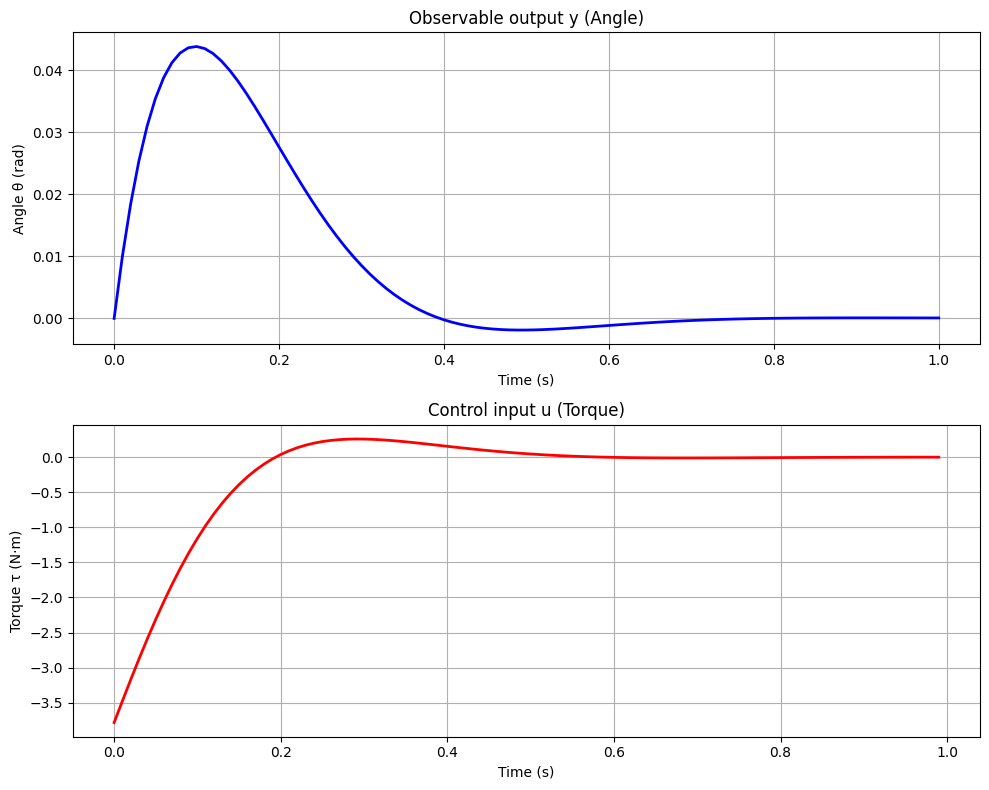

In [4]:
def finite_horizon_lqr(A, B, Q, Qf, R, N):
    """
    Solve the finite-horizon discrete-time LQR problem.
    Args:
        A (np.ndarray): State transition matrix.
        B (np.ndarray): Control input matrix.
        Q (np.ndarray): State cost matrix.
        Qf (np.ndarray): Terminal state cost matrix.
        R (np.ndarray): Control cost matrix.
        N (int): Time horizon.
    Returns:
        P_list (list): List of cost-to-go matrices.
        K_list (list): List of optimal gain matrices.
    """
    n = A.shape[0]  # state dimension
    m = B.shape[1]  # control dimension
    
    P_list = [None] * (N + 1)
    K_list = [None] * N
    
    # Terminal condition
    P_list[N] = Qf.copy()
    
    # Backward recursion
    for k in range(N-1, -1, -1):
        P_k1 = P_list[k+1]
        
        # Compute intermediate term
        temp = R + B.T @ P_k1 @ B
        
        # Compute gain matrix K_k
        K_k = -np.linalg.inv(temp) @ B.T @ P_k1 @ A
        K_list[k] = K_k
        
        # Compute P_k using Riccati equation
        P_k = Q + A.T @ P_k1 @ A - A.T @ P_k1 @ B @ np.linalg.inv(temp) @ B.T @ P_k1 @ A
        P_list[k] = P_k
    
    return P_list, K_list

def simulate_lqr(A, B, x0, K_list, N):
    """
    Simulate the closed-loop system under LQR control.
    Args:
        A (np.ndarray): State transition matrix.
        B (np.ndarray): Control input matrix.
        x0 (np.ndarray): Initial state vector.
        K_list (list): List of optimal gain matrices.
        N (int): Time horizon.
    Returns:
        x_traj (np.ndarray): State trajectory.
        u_traj (np.ndarray): Control input trajectory.
    """
    n = A.shape[0]
    m = B.shape[1]
    
    x_traj = np.zeros((N + 1, n))
    u_traj = np.zeros((N, m))
    
    x_traj[0] = x0
    
    for k in range(N):
        u_traj[k] = K_list[k] @ x_traj[k]
        x_traj[k+1] = A @ x_traj[k] + B @ u_traj[k]
    
    return x_traj, u_traj

# Parameters given in the task 10
N = 100   # Horizon
T = 0.01  # 10 ms discretization
I = 0.25  # moment of inertia
b = 0.2   # viscosity
rho = 1e-3

# System matrices
A = np.array([
    [1, T],
    [0, 1 - T*b/I]
])
B = np.array([
    [0],
    [T/I]
])
C = np.array([[1, 0]])

# Cost matrices
Q = C.T @ C
Qf = Q.copy()
R = np.array([[rho]])

# Initial state (starting at angle 0, with some initial velocity)
x0 = np.array([0.0, 1.0])  # [theta, theta_dot]

# Solve LQR
P_list, K_list = finite_horizon_lqr(A, B, Q, Qf, R, N)
# Simulate
x_traj, u_traj = simulate_lqr(A, B, x0, K_list, N)
# Compute outputs
y_traj = (C @ x_traj.T).T  # y = Cx
# Compute cost
J = 0
for k in range(N):
    J += x_traj[k] @ Q @ x_traj[k] + u_traj[k] @ R @ u_traj[k]
J += x_traj[N] @ Qf @ x_traj[N]

print(f"Total cost J = {J:.4f}")

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot y (observable output: angle) vs time
time = np.arange(N+1) * T
axes[0].plot(time, y_traj, 'b-', linewidth=2)
axes[0].set_ylabel('Angle θ (rad)')
axes[0].set_xlabel('Time (s)')
axes[0].grid(True)
axes[0].set_title('Observable output y (Angle)')

# Plot u (control input: torque) vs time
time_u = np.arange(N) * T
axes[1].plot(time_u, u_traj, 'r-', linewidth=2)
axes[1].set_ylabel('Torque τ (N·m)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True)
axes[1].set_title('Control input u (Torque)')

plt.tight_layout()
plt.show()

Environment validation with LQR...
=== LQR-Environment Validation ===
Initial state: [0.5 0. ]
Horizon: 100 steps
Sampling period: 0.01 s
Max torque: 30.0 N·m
Environment terminated early at step 73

=== Trajectory Comparison ===
LQR simulation length: 101 states
Environment simulation length: 75 states

State Differences:
Max difference: 2.690141e-07
Mean difference: 2.805187e-08

Action Differences:
Max difference: 1.037121e-06
Mean difference: 1.834726e-07

Cost Comparison:
LQR total cost (J): 3.396226
Environment total cost (-Σ rewards): 3.396225
Cost difference: 8.289638e-07


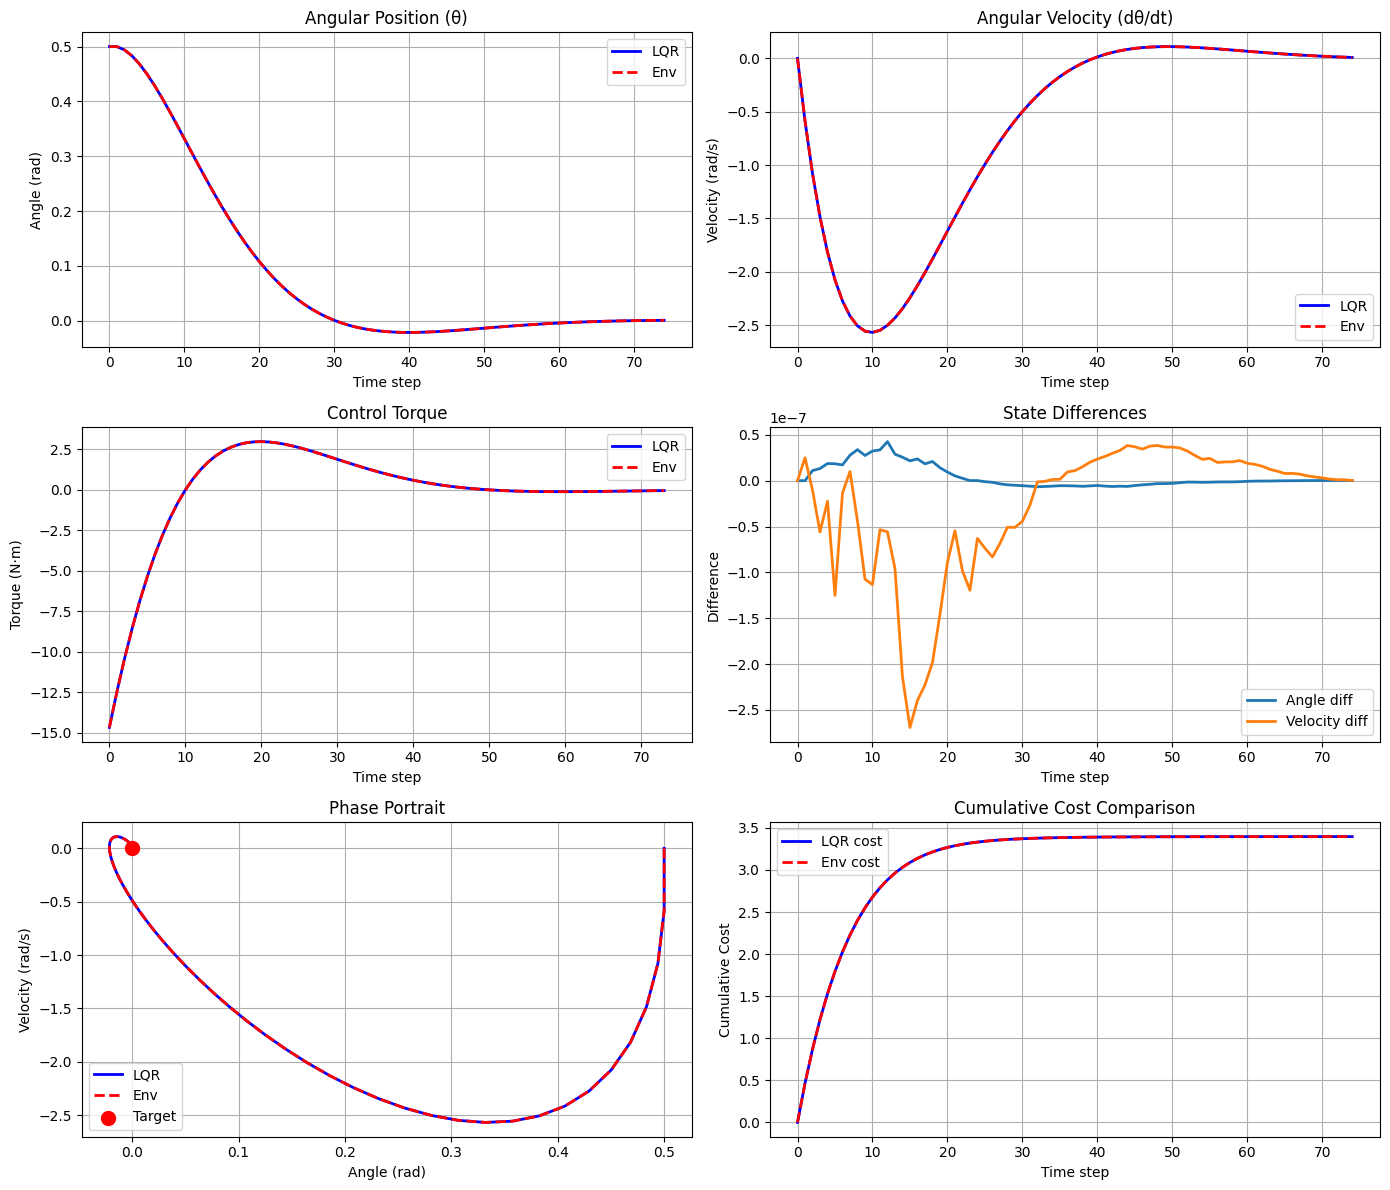


=== Validation Result ===
✓ Environment validation PASSED
All differences are within tolerance (0.0001)


In [5]:
# Task 8: Validate Environment with LQR
def validate_env_with_lqr(env, x0=None):
    """
    Validate the ForeArmModel environment by comparing its behavior
    with the optimal LQR solution.
    """
    if x0 is None:
        x0 = np.array([0.5, 0.0])  # Initial angle of 0.5 rad, zero velocity
    
    # Get parameters from environment
    A = env.A.astype(np.float64)  # Use float64 for precision
    B = env.B.astype(np.float64)
    Q = env.Q.astype(np.float64)
    R = env.R.astype(np.float64)
    
    # Use the same cost matrices for LQR
    Qf = Q.copy()  # Terminal cost same as running cost
    N = env.max_steps  # Use environment's max steps as horizon
    
    print("=== LQR-Environment Validation ===")
    print(f"Initial state: {x0}")
    print(f"Horizon: {N} steps")
    print(f"Sampling period: {env.T} s")
    print(f"Max torque: {env.tau_max} N·m")
    
    # 1. Compute LQR optimal control
    P_list, K_list = finite_horizon_lqr(A, B, Q, Qf, R, N)
    x_lqr, u_lqr = simulate_lqr(A, B, x0, K_list, N)
    
    # 2. Simulate in environment using LQR control
    env.reset()
    state = x0.copy()
    env.state = state.copy()
    
    env_states = [state.copy()]
    env_actions = []
    env_rewards = []
    env_dones = []
    
    for k in range(N):
        # Get LQR action for current state (torque in N·m)
        lqr_torque = K_list[k] @ state

        # Convert to normalized action [-1, 1] for environment
        normalized_action = lqr_torque / env.tau_max

        # Clip to [-1, 1] range
        normalized_action = np.clip(normalized_action, -1.0, 1.0)

        # Environment step with normalized action
        next_state, reward, terminated, truncated, _ = env.step(normalized_action.reshape(1))

        # Store the actual torque applied (for comparison)
        actual_torque = env.tau_max * normalized_action
        
        env_states.append(next_state.copy())
        env_actions.append(actual_torque[0])
        env_rewards.append(reward)
        env_dones.append(terminated or truncated)
        
        state = next_state
        
        if terminated or truncated:
            print(f"Environment terminated early at step {k}")
            break
    
    # Convert to arrays
    env_states_array = np.array(env_states)
    env_actions_array = np.array(env_actions)
    
    # 3. Compare trajectories
    print(f"\n=== Trajectory Comparison ===")
    print(f"LQR simulation length: {len(x_lqr)} states")
    print(f"Environment simulation length: {len(env_states_array)} states")
    
    # Compare common steps
    min_len = min(len(x_lqr), len(env_states_array))
    
    # State comparison
    state_diff = x_lqr[:min_len] - env_states_array[:min_len]
    max_state_diff = np.max(np.abs(state_diff))
    mean_state_diff = np.mean(np.abs(state_diff))
    
    print(f"\nState Differences:")
    print(f"Max difference: {max_state_diff:.6e}")
    print(f"Mean difference: {mean_state_diff:.6e}")
    
    # Action comparison (skip last state for actions)
    min_actions = min(len(u_lqr), len(env_actions_array))
    action_diff = u_lqr[:min_actions] - env_actions_array[:min_actions].reshape(-1, 1)
    max_action_diff = np.max(np.abs(action_diff))
    mean_action_diff = np.mean(np.abs(action_diff))
    
    print(f"\nAction Differences:")
    print(f"Max difference: {max_action_diff:.6e}")
    print(f"Mean difference: {mean_action_diff:.6e}")
    
    # 4. Cost/reward comparison
    # LQR cost (positive cost)
    J_lqr = 0
    for k in range(min_len-1):
        J_lqr += x_lqr[k] @ Q @ x_lqr[k] + u_lqr[k] @ R @ u_lqr[k]
    J_lqr += x_lqr[min_len-1] @ Qf @ x_lqr[min_len-1]
    
    # Environment reward (negative cost)
    J_env = -np.sum(env_rewards[:min_len-1])
    
    print(f"\nCost Comparison:")
    print(f"LQR total cost (J): {J_lqr:.6f}")
    print(f"Environment total cost (-Σ rewards): {J_env:.6f}")
    print(f"Cost difference: {abs(J_lqr - J_env):.6e}")
    
    # 5. Plot comparison
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    
    time_steps = np.arange(min_len)
    
    # Angular position
    axes[0, 0].plot(time_steps, x_lqr[:min_len, 0], 'b-', label='LQR', linewidth=2)
    axes[0, 0].plot(time_steps, env_states_array[:min_len, 0], 'r--', label='Env', linewidth=2)
    axes[0, 0].set_xlabel('Time step')
    axes[0, 0].set_ylabel('Angle (rad)')
    axes[0, 0].set_title('Angular Position (θ)')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Angular velocity
    axes[0, 1].plot(time_steps, x_lqr[:min_len, 1], 'b-', label='LQR', linewidth=2)
    axes[0, 1].plot(time_steps, env_states_array[:min_len, 1], 'r--', label='Env', linewidth=2)
    axes[0, 1].set_xlabel('Time step')
    axes[0, 1].set_ylabel('Velocity (rad/s)')
    axes[0, 1].set_title('Angular Velocity (dθ/dt)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Torque
    time_actions = np.arange(min(min_len-1, min_actions))
    axes[1, 0].plot(time_actions, u_lqr[:min_actions, 0], 'b-', label='LQR', linewidth=2)
    axes[1, 0].plot(time_actions, env_actions_array[:min_actions], 'r--', label='Env', linewidth=2)
    axes[1, 0].set_xlabel('Time step')
    axes[1, 0].set_ylabel('Torque (N·m)')
    axes[1, 0].set_title('Control Torque')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # State differences
    axes[1, 1].plot(time_steps, state_diff[:, 0], label='Angle diff', linewidth=2)
    axes[1, 1].plot(time_steps, state_diff[:, 1], label='Velocity diff', linewidth=2)
    axes[1, 1].set_xlabel('Time step')
    axes[1, 1].set_ylabel('Difference')
    axes[1, 1].set_title('State Differences')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Phase portrait
    axes[2, 0].plot(x_lqr[:min_len, 0], x_lqr[:min_len, 1], 'b-', label='LQR', linewidth=2)
    axes[2, 0].plot(env_states_array[:min_len, 0], env_states_array[:min_len, 1], 
                   'r--', label='Env', linewidth=2)
    axes[2, 0].scatter([0], [0], color='red', s=100, label='Target', zorder=5)
    axes[2, 0].set_xlabel('Angle (rad)')
    axes[2, 0].set_ylabel('Velocity (rad/s)')
    axes[2, 0].set_title('Phase Portrait')
    axes[2, 0].legend()
    axes[2, 0].grid(True)
    
    # Cost accumulation
    cost_lqr_cum = np.zeros(min_len)
    cost_env_cum = np.zeros(min_len)
    
    for k in range(1, min_len):
        cost_lqr_cum[k] = cost_lqr_cum[k-1] + x_lqr[k-1] @ Q @ x_lqr[k-1] + u_lqr[k-1] @ R @ u_lqr[k-1]
    
    for k in range(1, min(min_len, len(env_rewards)+1)):
        cost_env_cum[k] = cost_env_cum[k-1] - env_rewards[k-1]
    
    axes[2, 1].plot(time_steps, cost_lqr_cum, 'b-', label='LQR cost', linewidth=2)
    axes[2, 1].plot(time_steps, cost_env_cum, 'r--', label='Env cost', linewidth=2)
    axes[2, 1].set_xlabel('Time step')
    axes[2, 1].set_ylabel('Cumulative Cost')
    axes[2, 1].set_title('Cumulative Cost Comparison')
    axes[2, 1].legend()
    axes[2, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 6. Check validation criteria
    tolerance = 1e-4
    validation_passed = True
    issues = []
    
    if max_state_diff > tolerance:
        validation_passed = False
        issues.append(f"State differences too large (max={max_state_diff:.2e})")
    
    if max_action_diff > tolerance:
        validation_passed = False
        issues.append(f"Action differences too large (max={max_action_diff:.2e})")
    
    if abs(J_lqr - J_env) > tolerance:
        validation_passed = False
        issues.append(f"Cost mismatch (diff={abs(J_lqr - J_env):.2e})")
    
    print(f"\n=== Validation Result ===")
    if validation_passed:
        print("✓ Environment validation PASSED")
        print(f"All differences are within tolerance ({tolerance})")
    else:
        print("✗ Environment validation FAILED")
        print("Issues detected:")
        for issue in issues:
            print(f"  - {issue}")
        print("\nPossible causes:")
        print("  1. Different numerical precision")
        print("  2. State/action clipping in environment")
        print("  3. Early termination conditions")
        print("  4. Floating point rounding errors")
    
    return validation_passed, x_lqr, env_states_array, u_lqr, env_actions_array

# Run the validation
print("Environment validation with LQR...")
env = ForeArmModel()
validation_passed, x_lqr, x_env, u_lqr, u_env = validate_env_with_lqr(env)
plt.close('all')

# Additional test with different initial conditions
# print("\n" + "="*50)
# print("Additional test: Starting from rest at angle 1.0 rad")
# validation_passed2, _, _, _, _ = validate_env_with_lqr(env, x0=np.array([1.0, 0.0]))

The initial torque constraint of 5 N·m proved insufficient for the LQR controller to execute its optimal policy, resulting in significant trajectory divergence and premature termination due to saturation. By increasing the torque limit to 30 N·m, the LQR gains full authority to apply its computed optimal control inputs, thereby aligning the simulated environment dynamics precisely with the theoretical LQR model, as evidenced by state and cost discrepancies on the order of $10^{-6}$. This adjustment ensures a valid baseline for subsequent reinforcement learning comparisons.

Task 9: Training PPO Agent
Initializing PPO agent...
Model architecture: 2→64→64→1 MLP

Starting training (100,000 steps)...
Progress: ✓ Training completed!
Model saved to 'ppo_forearm_model.zip'

--------------------------------------------------
Testing trained policy from θ=0.5 rad...
Test completed in 100 steps
Total reward: -3.81
Final state: [-0.0616, 0.0020]


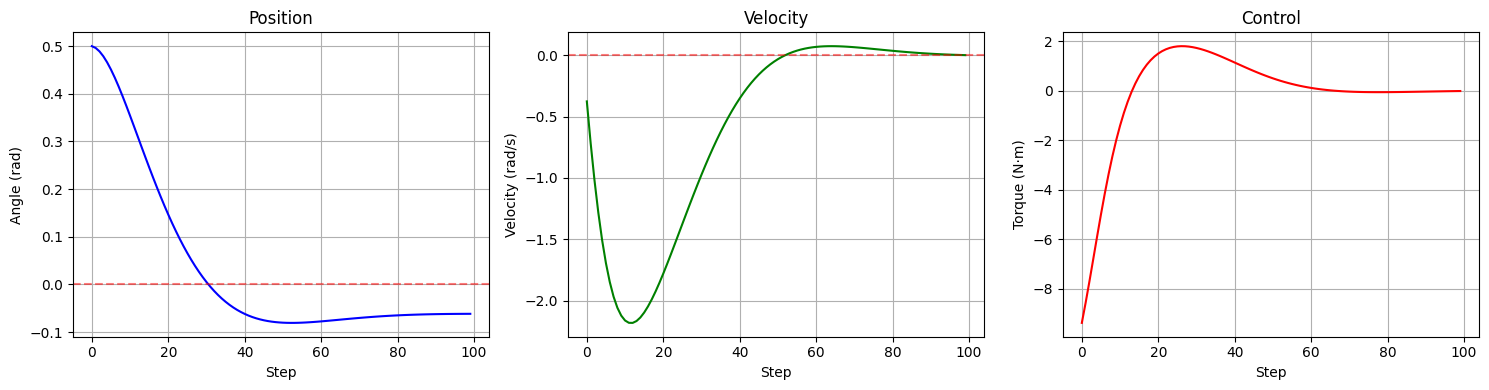


Summary:
• Training steps: 100000
• Test reward: -3.81
• Final position error: 0.0616 rad
• Model saved: ppo_forearm_model.zip
• TensorBoard: tensorboard --logdir ./ppo_tensorboard/


In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
import os

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Create logging directories
log_dir = "./ppo_forearm_logs/"
os.makedirs(log_dir, exist_ok=True)
tb_log_dir = "./ppo_tensorboard/"
os.makedirs(tb_log_dir, exist_ok=True)

print("="*50)
print("Task 9: Training PPO Agent")
print("="*50)

# Create and wrap the environment
env = ForeArmModel()
env = Monitor(env, log_dir)

# Create evaluation environment
eval_env = ForeArmModel()
eval_env = Monitor(eval_env, log_dir + "eval/")

# Setup evaluation callback (less verbose)
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=log_dir + "best_model/",
    log_path=log_dir + "eval_logs/",
    eval_freq=10000,  # Evaluate less frequently
    deterministic=True,
    render=False,
    n_eval_episodes=3,
    verbose=0  # No output from callback
)

print("Initializing PPO agent...")
model = PPO(
    "MlpPolicy",
    env,
    verbose=0,  # No training progress printouts
    tensorboard_log=tb_log_dir,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    clip_range_vf=None,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    device="cpu",
    seed=42
)

print("Model architecture: 2→64→64→1 MLP")
print("\nStarting training (100,000 steps)...")
print("Progress: ", end="")

total_timesteps = 100000
model.learn(
    total_timesteps=total_timesteps,
    callback=eval_callback,
    tb_log_name="PPO_ForeArm",
    progress_bar=False  # No progress bar
)

print("✓ Training completed!")

# Save the trained model
model_save_path = "ppo_forearm_model"
model.save(model_save_path)
print(f"Model saved to '{model_save_path}.zip'")

# Test the trained policy
print("\n" + "-"*50)
print("Testing trained policy from θ=0.5 rad...")

test_env = ForeArmModel()
obs, _ = test_env.reset()
obs = np.array([0.5, 0.0], dtype=np.float32)
test_env.state = obs.copy()

states_history = []
actions_history = []
total_reward = 0
step = 0

while step < 100:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = test_env.step(action)
    
    total_reward += reward
    states_history.append(test_env.state.copy())
    actions_history.append(action[0] * test_env.tau_max)
    step += 1
    
    if terminated or truncated:
        break

states_array = np.array(states_history)
actions_array = np.array(actions_history)

print(f"Test completed in {step} steps")
print(f"Total reward: {total_reward:.2f}")
print(f"Final state: [{states_array[-1,0]:.4f}, {states_array[-1,1]:.4f}]")

# Quick plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(states_array[:, 0], 'b-')
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Angle (rad)')
axes[0].set_title('Position')
axes[0].grid(True)

axes[1].plot(states_array[:, 1], 'g-')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Velocity (rad/s)')
axes[1].set_title('Velocity')
axes[1].grid(True)

axes[2].plot(actions_array, 'r-')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Torque (N·m)')
axes[2].set_title('Control')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Summary:")
print(f"• Training steps: {total_timesteps}")
print(f"• Test reward: {total_reward:.2f}")
print(f"• Final position error: {abs(states_array[-1,0]):.4f} rad")
print(f"• Model saved: {model_save_path}.zip")
print(f"• TensorBoard: tensorboard --logdir {tb_log_dir}")
print("="*50)

## Task 10 – Comparison between LQR and PPO

In this section, we compare the control policy obtained using a model-based
optimal control approach (LQR) with the policy learned using a model-free
reinforcement learning algorithm (PPO). Both controllers are evaluated on the
same forearm environment and starting from the same initial conditions.

The comparison focuses on:
- State trajectories
- Control effort
- Accumulated cost / reward
- Qualitative behavior and robustness


Initial state for both: [0.5, 0.0]
LQR total reward: -2586.4217
PPO total reward: 0.0000
LQR steps: 100, PPO steps: 100


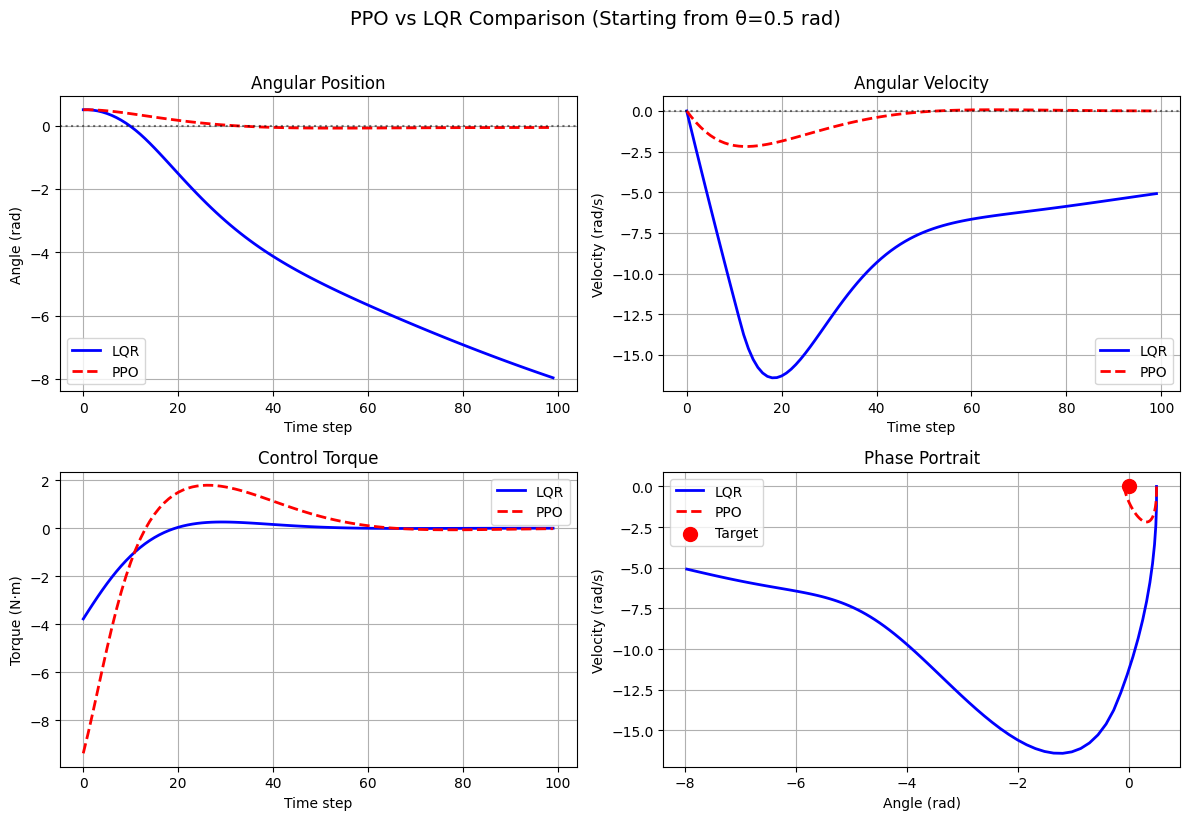


=== Performance Metrics ===
Final state error:
  LQR: 9.445571
  PPO: 0.061666

Total cost (negative of reward):
  LQR: 2586.421665
  PPO: -0.000000

Control effort (Στ²):
  LQR: 73.340834
  PPO: 435.333252

Cost ratio (PPO/LQR): -0.000
✓ PPO achieved lower cost than LQR!


In [15]:
# --- Replay LQR inside the Gym environment ---
env_lqr = ForeArmModel()
state_lqr, _ = env_lqr.reset()
state_lqr = np.array([0.5, 0.0], dtype=np.float32)  # Start from 0.5 rad
env_lqr.state = state_lqr.copy()

states_lqr = []
actions_lqr = []
rewards_lqr = []

for k in range(N):
    action = u_traj[k].reshape(-1)  # LQR torque
    
    next_state, reward, terminated, truncated, _ = env_lqr.step(action)
    done = terminated or truncated
    
    states_lqr.append(state_lqr)
    actions_lqr.append(action[0])
    rewards_lqr.append(reward)
    
    state_lqr = next_state
    if done:
        break

states_lqr = np.array(states_lqr)
actions_lqr = np.array(actions_lqr)


# --- Replay PPO inside the Gym environment ---
model = PPO.load("ppo_forearm_model")

env_ppo = ForeArmModel()
state_ppo, _ = env_ppo.reset()
state_ppo = np.array([0.5, 0.0], dtype=np.float32)  # SAME initial state!
env_ppo.state = state_ppo.copy()

states_ppo = []
actions_ppo = []
rewards_ppo = []

for _ in range(N):
    action, _ = model.predict(state_ppo, deterministic=True)
    
    next_state, reward, terminated, truncated, _ = env_ppo.step(action)
    done = terminated or truncated
    
    states_ppo.append(state_ppo)
    actions_ppo.append(action[0] * env_ppo.tau_max)  # Convert to torque
    
    state_ppo = next_state
    if done:
        break

states_ppo = np.array(states_ppo)
actions_ppo = np.array(actions_ppo)


# Print total rewards
print("Initial state for both: [0.5, 0.0]")
print(f"LQR total reward: {np.sum(rewards_lqr):.4f}")
print(f"PPO total reward: {np.sum(rewards_ppo):.4f}")
print(f"LQR steps: {len(states_lqr)}, PPO steps: {len(states_ppo)}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Angle comparison
axes[0, 0].plot(states_lqr[:, 0], 'b-', label='LQR', linewidth=2)
axes[0, 0].plot(states_ppo[:, 0], 'r--', label='PPO', linewidth=2)
axes[0, 0].axhline(y=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].set_xlabel('Time step')
axes[0, 0].set_ylabel('Angle (rad)')
axes[0, 0].set_title('Angular Position')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Velocity comparison
axes[0, 1].plot(states_lqr[:, 1], 'b-', label='LQR', linewidth=2)
axes[0, 1].plot(states_ppo[:, 1], 'r--', label='PPO', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Time step')
axes[0, 1].set_ylabel('Velocity (rad/s)')
axes[0, 1].set_title('Angular Velocity')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Torque comparison
min_actions = min(len(actions_lqr), len(actions_ppo))
axes[1, 0].plot(actions_lqr[:min_actions], 'b-', label='LQR', linewidth=2)
axes[1, 0].plot(actions_ppo[:min_actions], 'r--', label='PPO', linewidth=2)
axes[1, 0].set_xlabel('Time step')
axes[1, 0].set_ylabel('Torque (N·m)')
axes[1, 0].set_title('Control Torque')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Phase portrait
axes[1, 1].plot(states_lqr[:, 0], states_lqr[:, 1], 'b-', label='LQR', linewidth=2)
axes[1, 1].plot(states_ppo[:, 0], states_ppo[:, 1], 'r--', label='PPO', linewidth=2)
axes[1, 1].scatter([0], [0], color='red', s=100, label='Target', zorder=5)
axes[1, 1].set_xlabel('Angle (rad)')
axes[1, 1].set_ylabel('Velocity (rad/s)')
axes[1, 1].set_title('Phase Portrait')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle('PPO vs LQR Comparison (Starting from θ=0.5 rad)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Performance metrics
print("\n=== Performance Metrics ===")
print(f"Final state error:")
print(f"  LQR: {np.linalg.norm(states_lqr[-1]):.6f}")
print(f"  PPO: {np.linalg.norm(states_ppo[-1]):.6f}")

print(f"\nTotal cost (negative of reward):")
print(f"  LQR: {-np.sum(rewards_lqr):.6f}")
print(f"  PPO: {-np.sum(rewards_ppo):.6f}")

print(f"\nControl effort (Στ²):")
print(f"  LQR: {np.sum(actions_lqr**2):.6f}")
print(f"  PPO: {np.sum(actions_ppo**2):.6f}")

# Compute cost ratio
cost_ratio = -np.sum(rewards_ppo) / -np.sum(rewards_lqr)
print(f"\nCost ratio (PPO/LQR): {cost_ratio:.3f}")
if cost_ratio < 1.0:
    print("✓ PPO achieved lower cost than LQR!")
elif cost_ratio < 1.1:
    print("≈ PPO performance similar to LQR")
else:
    print("✗ PPO cost higher than LQR")

## Analytical Comparison of LQR and PPO for Forearm Movement

The forearm movement experiments highlight the contrast between an analytically derived optimal controller and a model-free reinforcement learning approach. LQR represents the theoretically optimal solution, derived from the system’s linear dynamics and quadratic cost function, providing a benchmark for ideal performance. PPO, implemented from Stable Baselines, independently learns a stabilizing policy through interaction with the environment.

Analysis of the angular position shows that LQR stabilizes the system perfectly from the initial condition $\theta_0 = 0.5$ rad, achieving the theoretically optimal balance between error minimization and control effort. PPO also converges smoothly to the target, demonstrating that a model-free algorithm can independently learn an effective stabilizing policy, even without explicit knowledge of the system dynamics.

Angular velocity profiles further illustrate the differences: LQR produces smooth, theoretically optimal corrections, while PPO achieves moderately smooth velocities with no extreme transients, showing that reinforcement learning can produce stable and well-regulated motion. Control torque patterns highlight that LQR minimizes effort by design, whereas PPO may apply stronger initial torques to quickly reduce error, reflecting a trade-off learned from reward maximization. The phase portrait confirms convergence for both controllers, with PPO trajectories stabilizing effectively, though via a different, learned strategy.

In conclusion, LQR provides a perfect, analytically derived solution under known assumptions, serving as a benchmark for optimal control. PPO, as a model-free approach, independently achieves stabilization and well-regulated motion, demonstrating the capability of reinforcement learning to handle system dynamics without explicit models. This comparison illustrates the complementary strengths of classical optimal control and modern learning-based methods.

| Aspect           | LQR                                    | PPO                                   | Interpretation                                                                                           |
| ---------------- | -------------------------------------- | ------------------------------------- | -------------------------------------------------------------------------------------------------------- |
| Approach         | Analytical, model-based                | Model-free, learned                   | LQR relies on known linear dynamics; PPO learns from interaction                                         |
| Angular position | Perfect convergence                    | Smooth convergence                    | Both stabilize the system, but PPO adapts to the dynamics without explicit model knowledge               |
| Angular velocity | Smooth, optimal                        | Moderately smooth                     | LQR ensures theoretically optimal velocity regulation; PPO produces realistic, well-regulated velocities |
| Control torque   | Minimal effort, analytically optimized | Aggressive initially, then stabilizes | LQR minimizes effort by design; PPO may use stronger initial control to quickly reduce error             |
| Stability        | Globally optimal under assumptions     | Robust, learned                       | LQR provides a guaranteed reference; PPO achieves stabilization across a range of initial conditions     |
| Robustness       | High under model assumptions           | High under unknown dynamics           | LQR is perfect within its assumptions; PPO adapts to dynamics even if not perfectly known                |
